# Data Science & ML Job Salaries – EDA

**Fragestellung:** Was bestimmt das Gehalt als Data Scientist oder Machine Learning Engineer?

**Datensatz:** [Data Science Salaries 2024 – Kaggle](https://www.kaggle.com/datasets/sazidthe1/data-science-salaries)  
**Quelle:** ai-jobs.net | Zeitraum: 2020–2024

## 1. Setup & Imports

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Plot-Stil
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)

print(f"pandas: {pd.__version__}")

pandas: 3.0.2


## 2. Daten laden & ersten Überblick verschaffen

In [2]:
# Load dataset
df_raw = pd.read_csv("../data/raw/data_science_salaries.csv")
df = df_raw.copy()

# dimension 
print(df_raw.shape)
print(df_raw.size)

(6599, 11)
72589


In [3]:
# structure
#print(df_raw.head(3))
#print(df_raw.tail(3))
df_raw.sample(10)



,job_title,experience_level,employment_type,work_models,work_year,employee_residence,salary,salary_currency,salary_in_usd,company_location,company_size
3937,Machine Learning Engineer,Senior-level,Full-time,Remote,2023,Portugal,150000,USD,150000,United States,Medium
1306,Business Intelligence Engineer,Senior-level,Full-time,On-site,2023,United States,156400,USD,156400,United States,Medium
647,Data Scientist,Entry-level,Full-time,On-site,2023,United States,113800,USD,113800,United States,Medium
5199,Data Analyst,Entry-level,Part-time,Remote,2022,United States,34320,USD,34320,United States,Small
2652,Data Engineer,Senior-level,Full-time,Remote,2023,United States,129000,USD,129000,United States,Medium
4101,Data Analyst,Mid-level,Full-time,Remote,2023,United States,83500,USD,83500,United States,Medium
3603,Research Engineer,Mid-level,Full-time,On-site,2023,United States,155000,USD,155000,United States,Medium
6307,Data Analyst,Entry-level,Full-time,Remote,2022,Argentina,50000,USD,50000,Argentina,Large
4231,Data Analyst,Senior-level,Full-time,On-site,2023,United States,230000,USD,230000,United States,Medium
4871,Data Analyst,Mid-level,Full-time,On-site,2023,United Kingdom,36050,GBP,44356,United Kingdom,Medium


In [4]:
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 6599 entries, 0 to 6598
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   job_title           6599 non-null   str  
 1   experience_level    6599 non-null   str  
 2   employment_type     6599 non-null   str  
 3   work_models         6599 non-null   str  
 4   work_year           6599 non-null   int64
 5   employee_residence  6599 non-null   str  
 6   salary              6599 non-null   int64
 7   salary_currency     6599 non-null   str  
 8   salary_in_usd       6599 non-null   int64
 9   company_location    6599 non-null   str  
 10  company_size        6599 non-null   str  
dtypes: int64(3), str(8)
memory usage: 567.2 KB


In [5]:
df_raw.describe()

,work_year,salary,salary_in_usd
count,6599.000000,6.599000e+03,6599.000000
mean,2022.818457,1.792833e+05,145560.558569
std,0.674809,5.263722e+05,70946.838070
min,2020.000000,1.400000e+04,15000.000000
25%,2023.000000,9.600000e+04,95000.000000
50%,2023.000000,1.400000e+05,138666.000000
75%,2023.000000,1.875000e+05,185000.000000
max,2024.000000,3.040000e+07,750000.000000


In [6]:
# Missing Values
df_raw.isnull().sum()

job_title             0
experience_level      0
employment_type       0
work_models           0
work_year             0
employee_residence    0
salary                0
salary_currency       0
salary_in_usd         0
company_location      0
company_size          0
dtype: int64

## 3. Gehalts-Entwicklung über die Jahre (2020–2024)

In [7]:
salary_by_year = (df
                  .groupby("work_year")["salary_in_usd"]
                  .agg(mean = "mean", median = "median", count = "count")
                  .round({"mean" : 2, "median" : 2})
                  .reset_index())
salary_by_year


,work_year,mean,median,count
0,2020,102250.87,79833.0,75
1,2021,99501.29,82636.0,216
2,2022,131788.54,130000.0,1112
3,2023,150791.42,143000.0,4625
4,2024,153124.08,138000.0,571


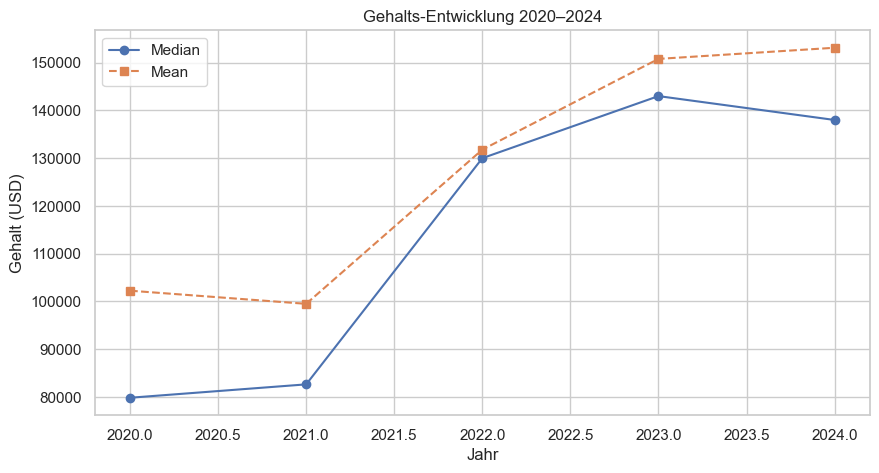

In [8]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(salary_by_year["work_year"], salary_by_year["median"], marker="o", label = "Median")
ax.plot(salary_by_year["work_year"], salary_by_year["mean"], marker="s", linestyle="--", label = "Mean")

ax.set_title("Gehalts-Entwicklung 2020–2024")
ax.set_xlabel("Jahr")
ax.set_ylabel("Gehalt (USD)")

ax.legend()

plt.show()

/var/folders/_d/4llk731n547f811mb_kz1m2h0000gn/T/ipykernel_41985/4126566816.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


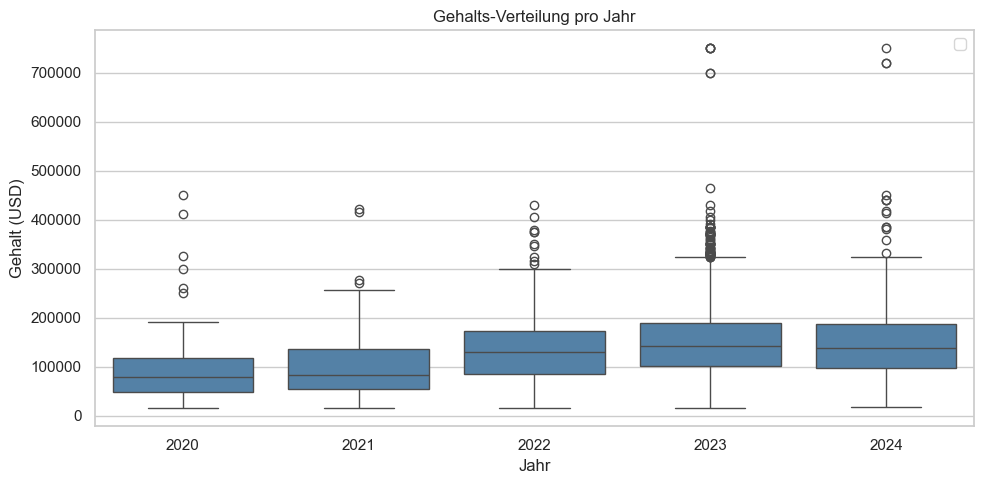

In [9]:
fig, ax = plt.subplots(figsize=(10, 5))

sns.boxplot(data=df, x="work_year", y="salary_in_usd", ax=ax, color="steelblue")

ax.set_title("Gehalts-Verteilung pro Jahr")
ax.set_xlabel("Jahr")
ax.set_ylabel("Gehalt (USD)")

ax.legend()

plt.tight_layout()

plt.show()



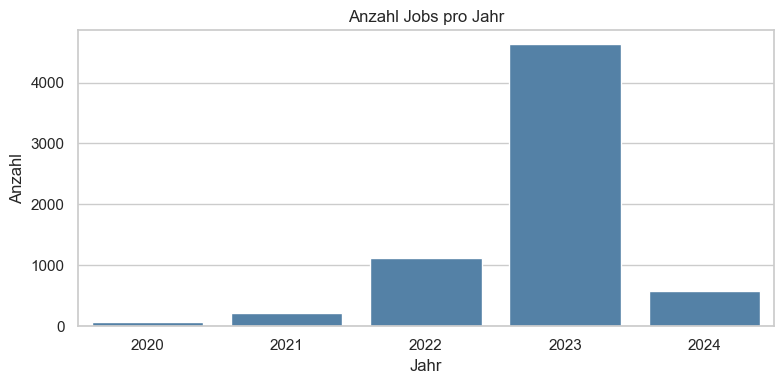

In [10]:
fig, ax = plt.subplots(figsize=(8,4))

sns.barplot(data=salary_by_year,x = "work_year", y = "count", ax=ax, color="steelblue")

ax.set_title("Anzahl Jobs pro Jahr")
ax.set_xlabel("Jahr")
ax.set_ylabel("Anzahl")
plt.tight_layout()
plt.show()

## 4. Einfluss des Erfahrungslevels (Junior → Senior → Executive)

In [11]:
salary_by_experience = (df
        .groupby("experience_level")["salary_in_usd"]
        .agg(mean = "mean", median = "median", count = "count")
        .round({"mean" : 2, "median" : 2})
        .reset_index()
        )
salary_by_experience

,experience_level,mean,median,count
0,Entry-level,84448.92,75000.0,565
1,Executive-level,189687.35,184560.0,254
2,Mid-level,119019.81,106500.0,1675
3,Senior-level,162071.06,153600.0,4105


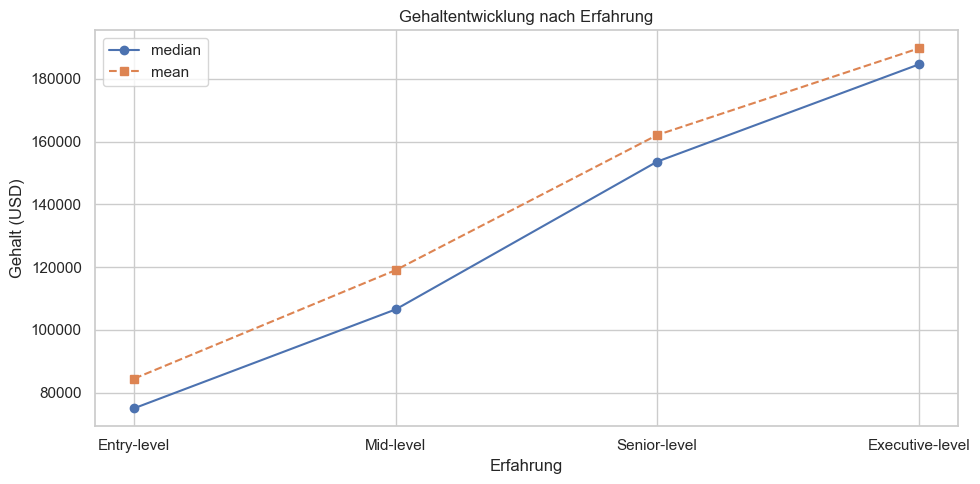

In [12]:
# Richtige Reihenfolge definieren
order = ["Entry-level", "Mid-level", "Senior-level", "Executive-level"]

# DataFrame in dieser Reihenfolge sortieren
salary_by_experience = salary_by_experience.set_index("experience_level").loc[order].reset_index()

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(salary_by_experience["experience_level"], salary_by_experience["median"], label="median", marker="o")
ax.plot(salary_by_experience["experience_level"], salary_by_experience["mean"], label="mean", linestyle="--", marker="s")

ax.set_title("Gehaltentwicklung nach Erfahrung")
ax.set_xlabel("Erfahrung")
ax.set_ylabel("Gehalt (USD)")

ax.legend()
plt.tight_layout()
plt.show()

NameError: name 'ds_salaries' is not defined

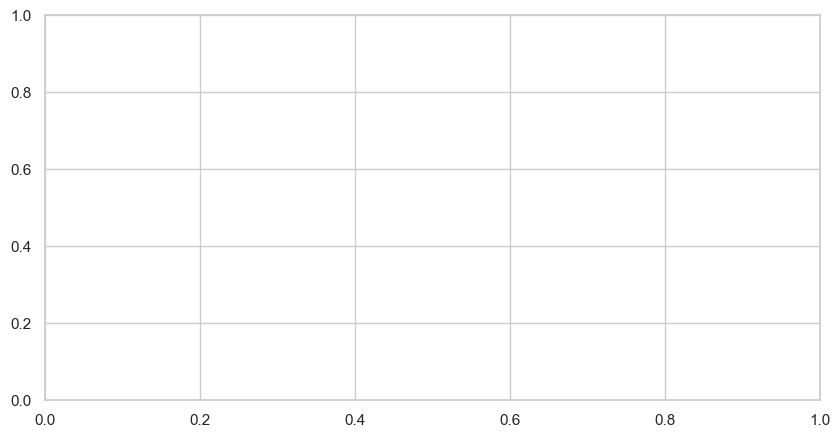

In [13]:
fig, ax = plt.subplots(figsize = (10,5))

sns.boxplot(data=ds_salaries, x="experience_level",y="salary_in_usd",order=["Entry-level", "Mid-level", "Senior-level", "Executive-level"])

ax.set_title("Gehalts-Verteilung nach Erfahrung")
ax.set_xlabel("Erfahrung")
ax.set_ylabel("Gehalt (USD)")

ax.legend()

plt.tight_layout()

plt.show()

## 5. Top & Bottom Job-Titel nach Gehalt

### Methodische Entscheidung: Minimum-Threshold für Job-Titel

Nicht alle 132 Job-Titel im Datensatz eignen sich für einen stabilen Gehaltsvergleich.
Die Verteilung der Einträge pro Job-Titel ist stark rechtsschief: Titel wie *Data Scientist*
(n=1.243) oder *Data Engineer* (n=1.307) dominieren, während mehr als die Hälfte aller
Titel weniger als 6 Einträge aufweist (Median der Häufigkeiten = 6).

Ein Median aus wenigen Datenpunkten ist statistisch nicht stabil — Ausreißer einzelner
Gehaltsmeldungen würden das Ergebnis zufällig verzerren.

**Entscheidung:** Nur Job-Titel mit mindestens **30 Einträgen** werden in die Analyse
einbezogen. Diese Faustformel basiert auf dem Central Limit Theorem: Ab ~30 Beobachtungen
nähert sich die Stichprobenverteilung einer Normalverteilung an, was statistische Aussagen
deutlich stabiler macht.

**Limitation:** Mögliche Label-Inkonsistenzen (z.B. *BI Analyst* vs.
*Business Intelligence Analyst*) wurden nicht bereinigt, da eine inhaltliche Gleichsetzung
nicht mit Sicherheit belegt werden kann. Die tatsächliche Sample Size vergleichbarer Rollen
könnte in Einzelfällen höher liegen.

In [68]:

job_title_counts = df["job_title"].value_counts()
job_title_median = job_title_counts.median()  # = 6.0 — zu niedrig, siehe Markdown oben


job_title_counts_filtered = job_title_counts[job_title_counts >= 30]

job_title_counts_filtered


job_title
Data Engineer                               1307
Data Scientist                              1243
Data Analyst                                 910
Machine Learning Engineer                    629
Analytics Engineer                           246
Research Scientist                           206
Data Architect                               176
Research Engineer                            136
ML Engineer                                  113
Applied Scientist                             97
Data Science Manager                          86
Business Intelligence Analyst                 82
Machine Learning Scientist                    73
Business Intelligence Engineer                69
Data Manager                                  63
Research Analyst                              60
Data Science                                  56
AI Engineer                                   48
Data Specialist                               47
Data Science Consultant                       42
BI Develop

### Beobachtung: Extreme Gehaltsspannen bei ML/AI-Rollen

Der Vergleich von Min-, Max- und Median-Gehalt zeigt bei mehreren Job-Titeln 
extreme Spannen. Besonders auffällig: *Machine Learning Engineer*, 
*Machine Learning Scientist* und *Research Scientist* weisen Max-Werte von 
bis zu 750.000 USD auf — bei Median-Werten zwischen 165k und 190k USD.

**Mögliche Erklärungen:**
- **Top-Tech-Firmen** (z.B. Google, Meta, OpenAI) zahlen für Senior-Positionen 
  tatsächlich außergewöhnlich hohe Gesamtvergütungen (Base + Bonus + Equity)
- **Falsch eingetragene Werte:** Da der Datensatz auf freiwilliger Selbstangabe 
  basiert (ai-jobs.net), sind Eingabefehler nicht auszuschließen

**Wichtig:** Mehrere Einträge zeigen Max-Werte im 700k–750k-Bereich — es handelt 
sich also nicht um einen einzelnen Ausreißer. Eine pauschale Bereinigung wäre 
daher nicht gerechtfertigt, da zumindest ein Teil dieser Werte plausibel sein 
könnte.

**Konsequenz für die Analyse:** Der Median bleibt die robuste Kennzahl für den 
Gehaltsvergleich — er wird durch solche Extremwerte nicht verzerrt.

**Weitere Datenqualitäts-Beobachtung:** Im gefilterten Ranking tauchen mutmaßlich 
synonyme Job-Titel separat auf — z.B. *ML Engineer* (n=113) und 
*Machine Learning Engineer* (n=629), sowie *Data Science* (n=56) und 
*Data Scientist* (n=1.243). Eine Zusammenführung dieser Titel wurde bewusst 
vermieden, da nicht mit Sicherheit belegt werden kann, dass sie in allen 
Unternehmen identische Rollen beschreiben. Eine Bereinigung würde eine Annahme 
in die Daten einbringen, die nicht aus dem Datensatz selbst ableitbar ist.

In [67]:
df_filtered = df[df["job_title"].isin(job_title_counts_filtered.index.to_list())]

df_job_title_grouped = (df_filtered.groupby("job_title").agg(
    count = ("job_title", "count"),
    min_salary = ("salary_in_usd", "min"),
    max_salary = ("salary_in_usd", "max"),
    median_salary = ("salary_in_usd", "median")
)).sort_values(by="median_salary", ascending=False).reset_index()

df_job_title_grouped

,job_title,count,min_salary,max_salary,median_salary
0,Director of Data Science,31,57786,375500,203016.0
1,Applied Scientist,97,20000,414000,191475.0
2,ML Engineer,113,15966,385000,189400.0
3,Data Science Manager,86,38915,328000,175000.0
4,Machine Learning Engineer,629,20000,750000,170730.0
5,Machine Learning Scientist,73,22800,750000,170000.0
6,Research Engineer,136,16455,720000,167250.0
7,Machine Learning Infrastructure Engineer,31,50180,260000,165400.0
8,Research Scientist,206,23000,720000,165250.0
9,AI Engineer,48,21593,372000,163000.0


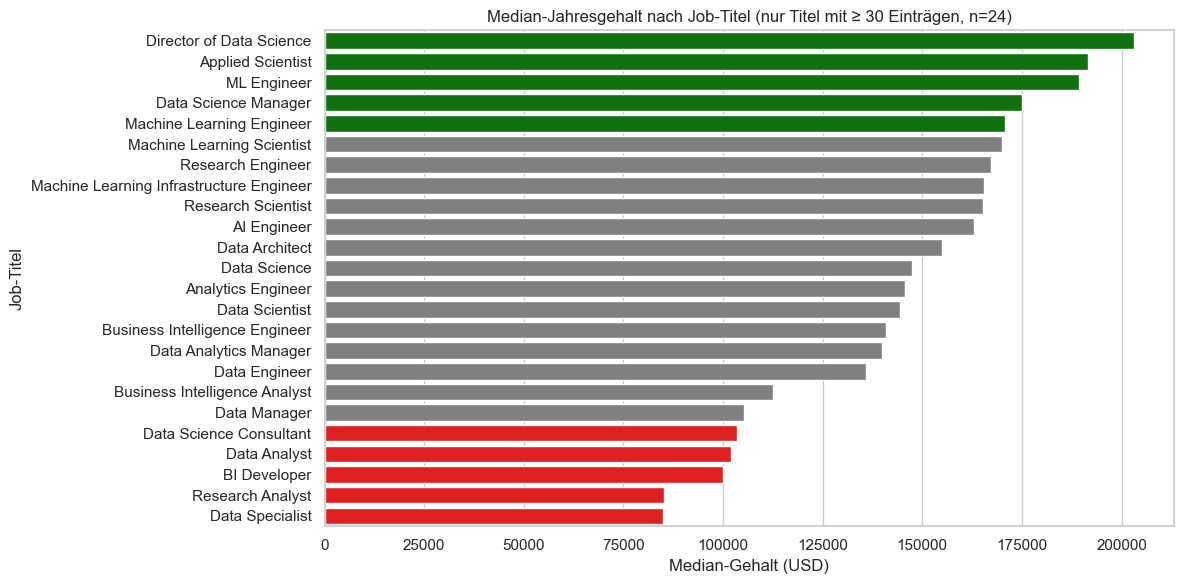

In [66]:
fig, ax = plt.subplots(figsize=(12,6))

colors = ["grey"] * 24
colors[:5] = ["green"] * 5
colors[-5:] = ["red"] * 5

sns.barplot(data=df_job_title_grouped,x = "median_salary", y = "job_title", ax=ax, palette=colors, hue="job_title", legend=False)

ax.set_title("Median-Jahresgehalt nach Job-Titel (nur Titel mit ≥ 30 Einträgen, n=24)")
ax.set_xlabel("Median-Gehalt (USD)")
ax.set_ylabel("Job-Titel")
plt.tight_layout()
plt.show()

## 6. Remote-Arbeit: zahlt sich das aus?

## 7. Geografische Unterschiede: USA vs. Europa vs. Rest

      employee_residence       mean    median  count
0                Algeria  100000.00  100000.0      1
1         American Samoa   45555.00   45555.0      1
2                Andorra   50745.00   50745.0      1
3              Argentina   56444.44   60000.0      9
4                Armenia   33500.00   33500.0      2
..                   ...        ...       ...    ...
82  United Arab Emirates  100000.00  115000.0      3
83        United Kingdom  103392.37   91118.0    401
84         United States  157780.94  149000.0   5305
85            Uzbekistan   82000.00  100000.0      3
86               Vietnam   58480.00   50000.0      5

[87 rows x 4 columns]


,salary_currency,mean,median,count
0,AUD,78538.18,81838.0,11
1,BRL,26168.75,23739.0,4
2,CAD,99896.36,87738.0,39
3,CHF,101659.40,104697.0,5
4,CLP,40038.00,40038.0,1
5,DKK,31192.67,28609.0,3
6,EUR,67190.08,62211.0,292
7,GBP,88487.48,74221.0,334
8,HKD,65058.00,65058.0,1
9,HUF,29892.67,35735.0,3


## 8. Unternehmensgröße als Faktor

In [ ]:
salary_by_company = (df
                  .groupby("company_size")["salary_in_usd"]
                  .agg(mean = "mean", median = "median", count = "count")
                  .round({"mean" : 2, "median" : 2})
                  .reset_index())
salary_by_company

,company_size,mean,median,count
0,Large,120638.40,106000.0,569
1,Medium,149659.39,141562.5,5860
2,Small,87687.46,74500.0,170


/var/folders/_d/4llk731n547f811mb_kz1m2h0000gn/T/ipykernel_34925/1697485436.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


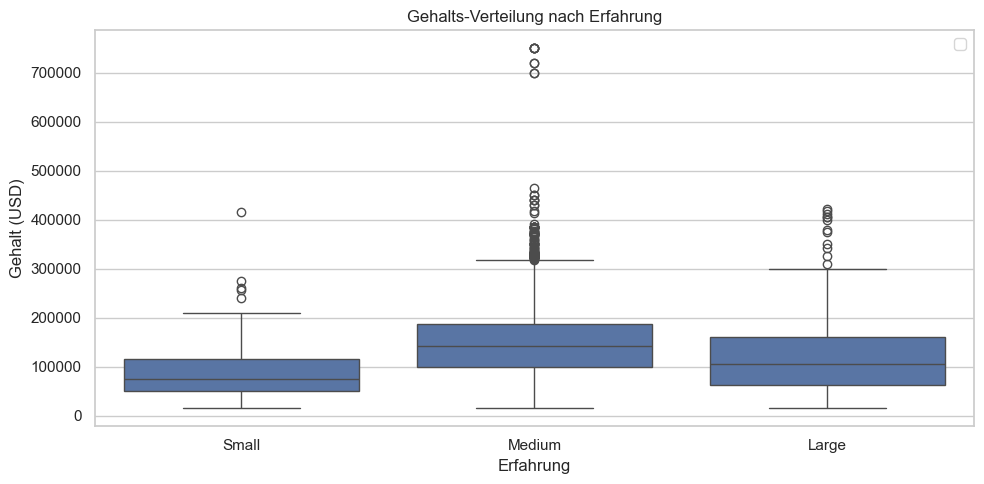

In [ ]:
fig, ax = plt.subplots(figsize = (10,5))

sns.boxplot(data=df, x="company_size",y="salary_in_usd",order=["Small", "Medium", "Large"])

ax.set_title("Gehalts-Verteilung nach Erfahrung")
ax.set_xlabel("Erfahrung")
ax.set_ylabel("Gehalt (USD)")

ax.legend()

plt.tight_layout()

plt.show()

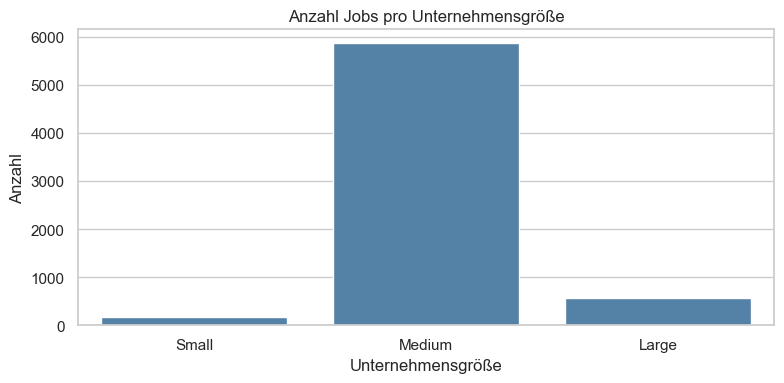

In [ ]:
fig, ax = plt.subplots(figsize=(8,4))

sns.barplot(data=salary_by_year,x = "company_size", y = "count", ax=ax, color="steelblue",order=["Small", "Medium", "Large"])

ax.set_title("Anzahl Jobs pro Unternehmensgröße")
ax.set_xlabel("Unternehmensgröße")
ax.set_ylabel("Anzahl")
plt.tight_layout()
plt.show()

**Hinweis zur Interpretation:** Der Datensatz ist stark auf mittelgroße Unternehmen konzentriert 
(~89% der Einträge, n≈5.860 vs. Large n≈569 vs. Small n≈170). 
Da die Daten auf freiwilliger Selbstangabe basieren (ai-jobs.net), besteht ein **Self-Selection Bias**: 
Mittelgroße Tech-Unternehmen und Startups sind auf solchen Plattformen überrepräsentiert, 
während Großkonzerne (z.B. durch NDAs) seltener vertreten sind. 
Die Gehaltsunterschiede zwischen den Unternehmensgrößen sollten daher nicht als strukturelles Ergebnis interpretiert werden, 
sondern als Artefakt der Datenerhebung.

## 9. Fazit & Key Findings

*(wird nach Abschluss der Analyse ausgefüllt)*